<a href="https://colab.research.google.com/github/Angappan95/langchain-practice/blob/main/10_langchain_memory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Short term memory

In [1]:
!pip install langchain langchain-core langchain-community langsmith langchain-google-genai python-dotenv tavily-python tavily -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 1.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


In [2]:
from google.colab import userdata
GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
TAVILY_API_KEY = userdata.get('TAVILY_API_KEY')

In [3]:
from langchain.agents import create_agent
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.messages import SystemMessage, HumanMessage, AIMessage
from langchain.tools import tool
from pprint import pprint

In [4]:
model = ChatGoogleGenerativeAI(model='gemini-3.1-flash-lite-preview', api_key=GOOGLE_API_KEY)
model

ChatGoogleGenerativeAI(profile={'name': 'Gemini 3.1 Flash Lite Preview', 'release_date': '2026-03-03', 'last_updated': '2026-03-03', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), model='gemini-3.1-flash-lite-preview', temperature=1.0, client=<google.genai.client.Client object at 0x7d6948d20590>, default_metadata=(), model_kwargs={})

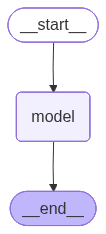

In [5]:
agent = create_agent(model=model)
agent

In [8]:
msg1 = [HumanMessage(content="Hey bot. I like red colour")]
msg2 = [HumanMessage(content="Hey bot. What colour do I like?")]

In [6]:
## by default all the llm requests are fire and forget. It doesnt retain the previous memory
response = agent.invoke({'messages': msg1})
pprint(response)

{'messages': [HumanMessage(content='Hey bot. I like red colour', additional_kwargs={}, response_metadata={}, id='674fb7f2-8bdb-43f1-a9d3-9e6f010509d0'),
              AIMessage(content=[{'type': 'text', 'text': 'That’s a bold and energetic choice! Red is a very powerful color. It’s often associated with passion, energy, strength, and excitement.\n\nWhat is it about red that you like? Do you prefer it in a specific shade, like a deep crimson, a bright cherry red, or maybe a fiery scarlet? \n\nAlso, are you a fan of having red things around you (like clothes or room decor), or do you just enjoy seeing it in nature and art?', 'extras': {'signature': 'EjQKMgEMOdbHIkGIiIwtX7VV5cgxnZdBLOjt8W5EP0wejUSHvwmKTpWFPlWt7SWYyIEXUItS'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019dee53-08e0-7780-a500-a29da94d8c9a-0', tool_calls=[], invalid_tool_calls=[], usage

In [7]:
response = agent.invoke({'messages': msg2})
pprint(response)

{'messages': [HumanMessage(content='Hey bot. What colour do I like?', additional_kwargs={}, response_metadata={}, id='c5b1553e-5950-49be-804e-821c93afe8a9'),
              AIMessage(content=[{'type': 'text', 'text': 'Since I don’t have access to your personal history or thoughts, I don’t know your favorite color yet!\n\nIf you tell me what it is, I can remember it for our future conversations. So, go ahead—**what is your favorite color?**', 'extras': {'signature': 'EjQKMgEMOdbHZ18kVHjddoBx2U+1Gus4UHyJVBY7+cZfou2269y1TzbzzL62zq6gZreCs93U'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019dee53-73c8-7612-9f47-7d2653ee7df9-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 10, 'output_tokens': 55, 'total_tokens': 65, 'input_token_details': {'cache_read': 0}})]}


In [11]:
from langgraph.checkpoint.memory import InMemorySaver

memory = InMemorySaver()

agent_with_memory = create_agent(model=model, checkpointer=memory)

config = {'configurable': {'thread_id': '1'}}

response1 = agent_with_memory.invoke({'messages': msg1}, config=config)
pprint(response1['messages'][-1])

response2 = agent_with_memory.invoke({'messages': msg2}, config=config)
pprint(response2['messages'][-1])

AIMessage(content=[{'type': 'text', 'text': 'Red is a fantastic choice! It’s such a bold, energetic, and powerful color.\n\nThere’s a lot to love about it—it’s the color of passion, excitement, and warmth. Because it’s so vibrant, it’s often associated with things that stand out, like fire, roses, sunsets, and even sports cars.\n\nWhat is it about red that you like so much? Do you like it because it’s bright and eye-catching, or is it more about the feeling it gives you?', 'extras': {'signature': 'EjQKMgEMOdbH+aAH2fYWbneuH5Vc4YQxVnPu2YcXSYiVNcPPqEYroit2is0pavBEKLw1NtFY'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019dee58-a40f-7643-b7b1-01dc126550ed-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 110, 'total_tokens': 118, 'input_token_details': {'cache_read': 0}})
AIMessage(content=[{'type': 'text', '